In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import warnings
warnings.filterwarnings("ignore")

In [2]:
df=pd.read_csv("Churn_Modelling.csv")

In [3]:
df.shape

(10000, 14)

In [4]:
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [6]:
df.isna().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

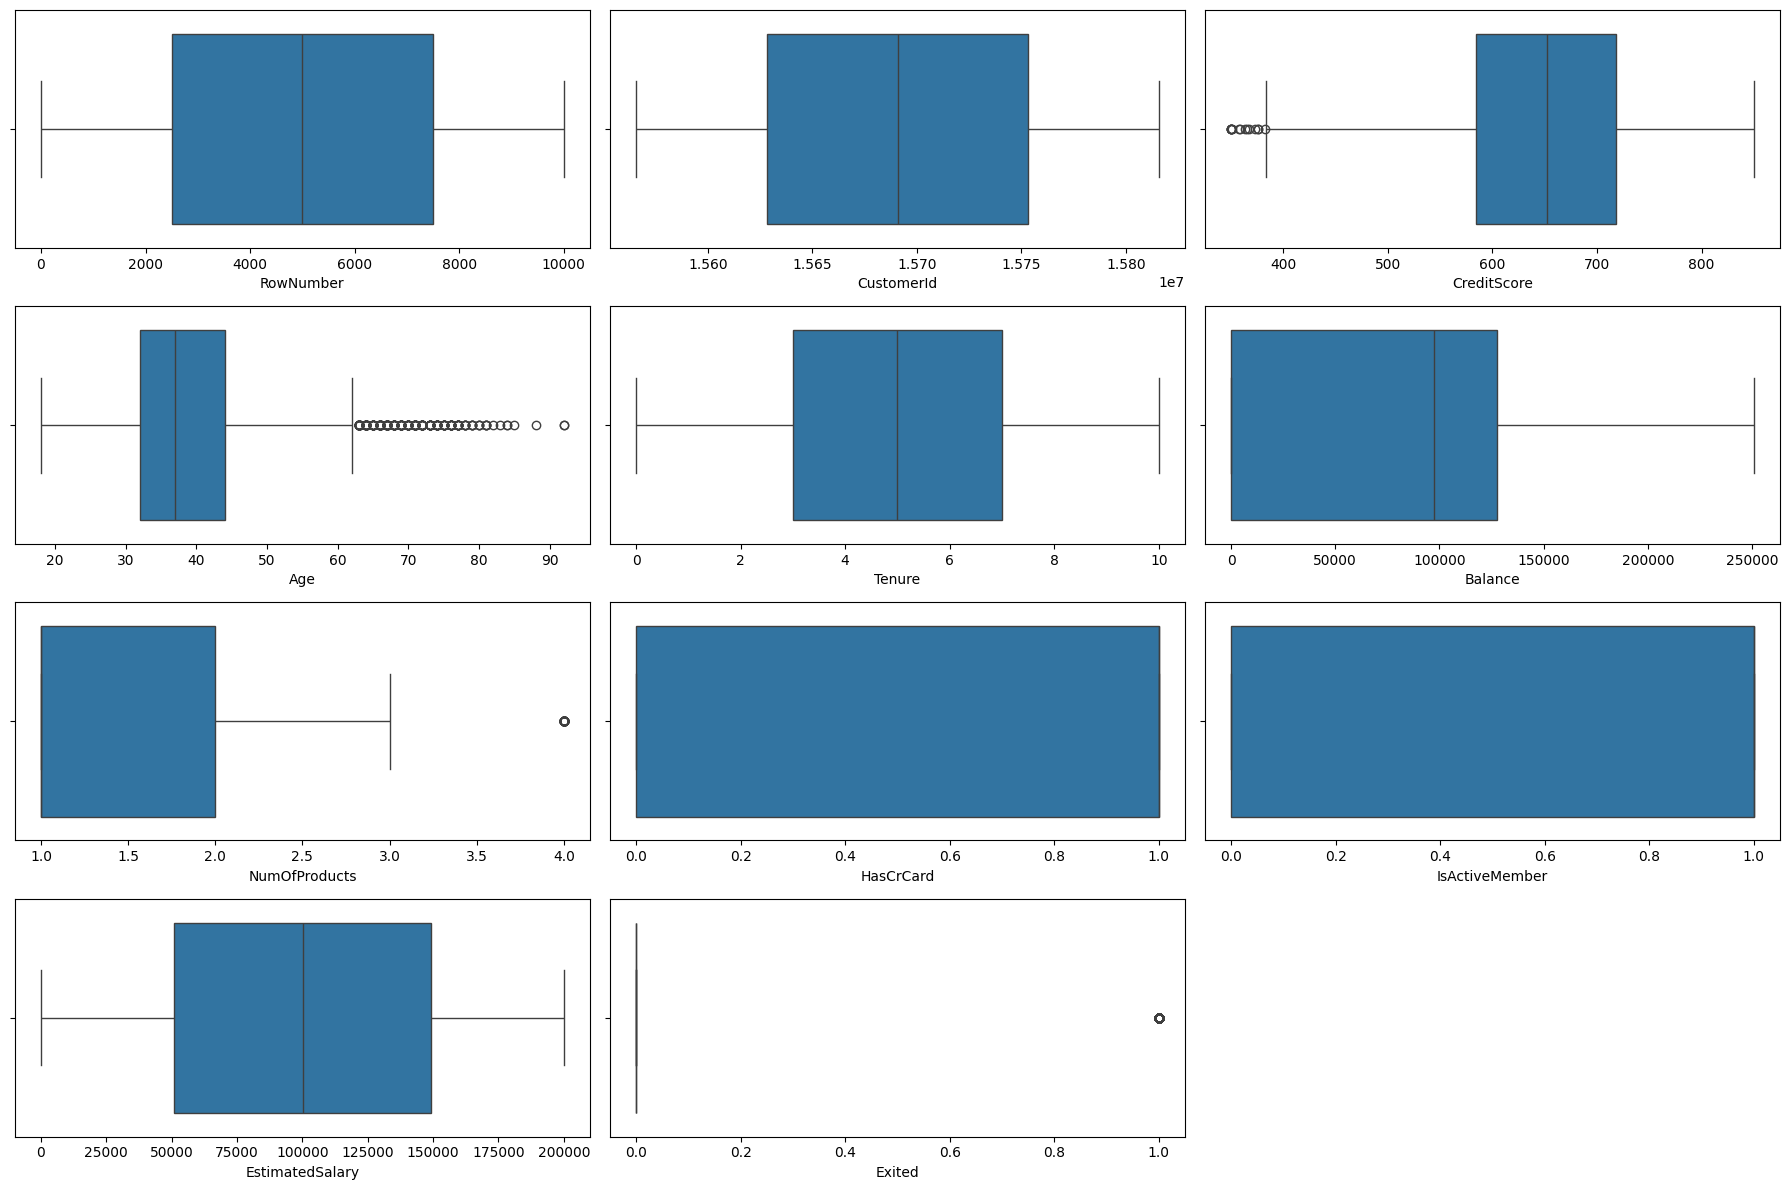

In [8]:
plt.figure(figsize=(18,12))
c=1
for i in df.describe().columns:
    plt.subplot(4,3,c)
    sns.boxplot(x=df[i])
    plt.tight_layout()
    c+=1

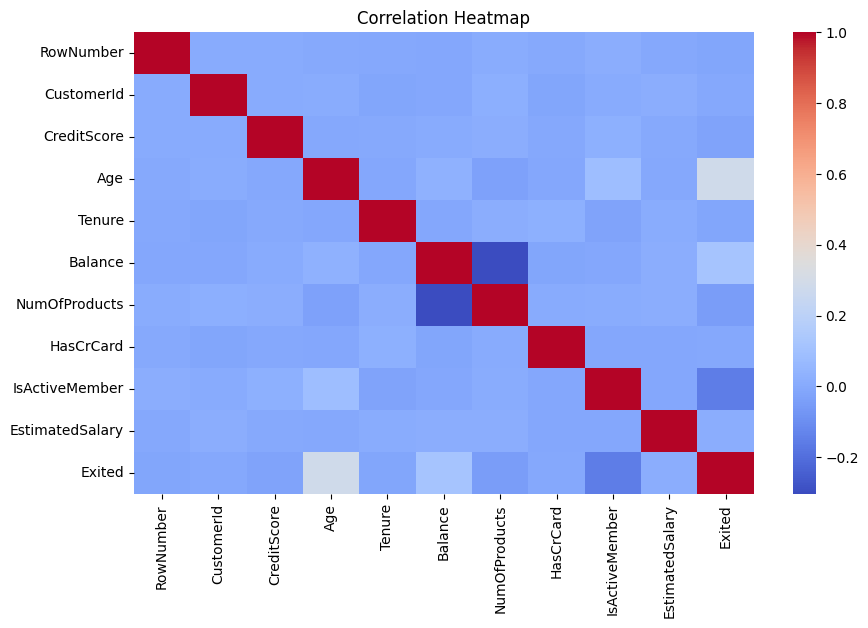

In [9]:
numeric_cols = df.select_dtypes(include=["int64", "float64"])
plt.figure(figsize=(10,6))
sns.heatmap(numeric_cols.corr(), cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [10]:
df.columns

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')

In [11]:
df.drop(columns=['RowNumber', 'CustomerId', 'Surname'],inplace=True)

Lower bound for outliers: 383.0
Upper bound for outliers: 919.0

Outliers in CreditScore after replacement:


,CreditScore


Total number of outliers after replacement: 0


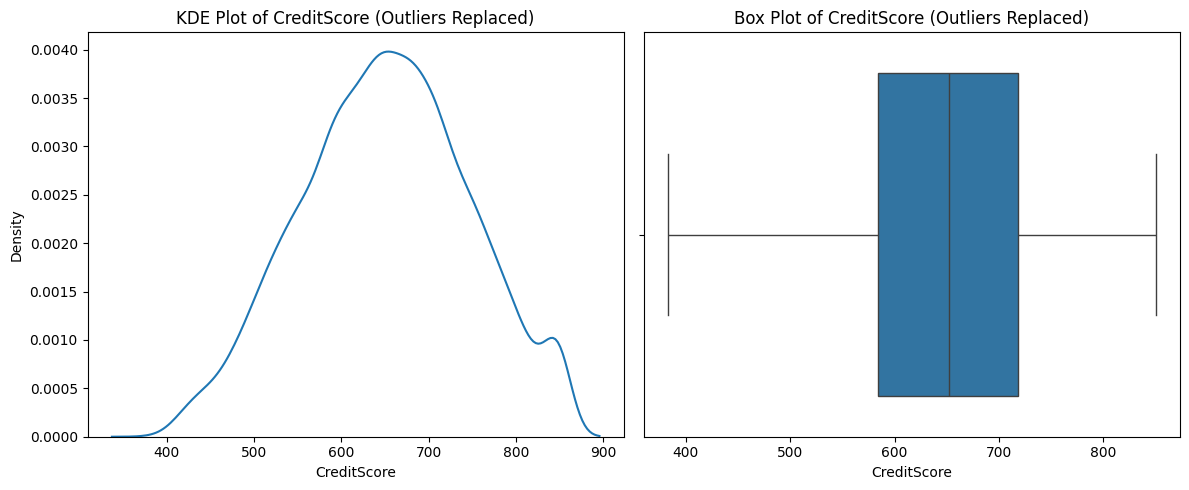

In [12]:
# Calculate Q1, Q3, and IQR for CreditScore
Q1 = df['CreditScore'].quantile(0.25)
Q3 = df['CreditScore'].quantile(0.75)
IQR = Q3 - Q1

# Define outlier bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

mean=df['CreditScore'].mean().round().astype(int)

# Replace outliers with the mean value 'mean'
df['CreditScore'] = np.where(df['CreditScore'] < lower_bound,mean,df['CreditScore'])
df['CreditScore'] = np.where(df['CreditScore'] > upper_bound,mean,df['CreditScore'])

print(f"Lower bound for outliers: {lower_bound}")
print(f"Upper bound for outliers: {upper_bound}")

# Display outliers (should be empty or very few after replacement)
outliers_after_replacement = df[(df['CreditScore'] < lower_bound) | (df['CreditScore'] > upper_bound)]
print("\nOutliers in CreditScore after replacement:")
display(outliers_after_replacement[['CreditScore']].head())
print(f"Total number of outliers after replacement: {len(outliers_after_replacement)}")

# Visualize the distribution after outlier treatment using KDE plot and box plot
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.kdeplot(df['CreditScore'])
plt.title('KDE Plot of CreditScore (Outliers Replaced)')

plt.subplot(1, 2, 2)
sns.boxplot(x=df['CreditScore'])
plt.title('Box Plot of CreditScore (Outliers Replaced)')
plt.tight_layout()
plt.show()

Lower bound for Age outliers: 14.0
Upper bound for Age outliers: 62.0

Outliers in Age before replacement:


,Age
58,66
85,75
104,65
158,73
181,65


Total number of outliers before replacement: 359

Outliers in Age after replacement:


,Age


Total number of outliers after replacement: 0


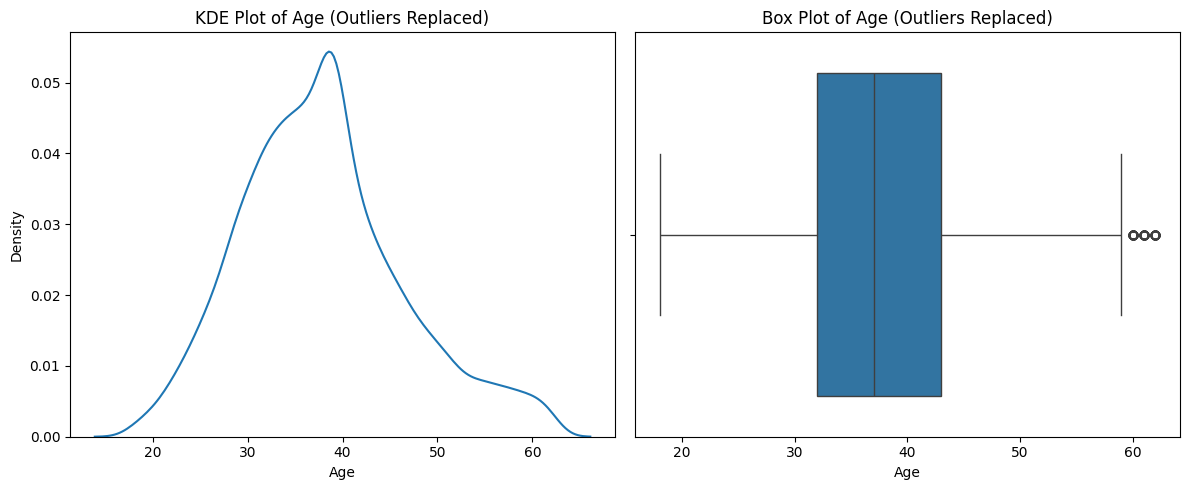

In [13]:
# Calculate the mean of 'Age'
mean_age = df['Age'].mean().round().astype(int)

# Calculate Q1, Q3, and IQR for Age
Q1_age = df['Age'].quantile(0.25)
Q3_age = df['Age'].quantile(0.75)
IQR_age = Q3_age - Q1_age

# Define outlier bounds for Age
lower_bound_age = Q1_age - 1.5 * IQR_age
upper_bound_age = Q3_age + 1.5 * IQR_age

print(f"Lower bound for Age outliers: {lower_bound_age}")
print(f"Upper bound for Age outliers: {upper_bound_age}")

# Display outliers before replacement
outliers_age_before_replacement = df[(df['Age'] < lower_bound_age) | (df['Age'] > upper_bound_age)]
print("\nOutliers in Age before replacement:")
display(outliers_age_before_replacement[['Age']].head())
print(f"Total number of outliers before replacement: {len(outliers_age_before_replacement)}")

# Replace outliers with the mean age
df['Age'] = np.where(df['Age'] < lower_bound_age, mean_age, df['Age'])
df['Age'] = np.where(df['Age'] > upper_bound_age, mean_age, df['Age'])

# Display outliers after replacement (should be empty or very few)
outliers_age_after_replacement = df[(df['Age'] < lower_bound_age) | (df['Age'] > upper_bound_age)]
print("\nOutliers in Age after replacement:")
display(outliers_age_after_replacement[['Age']].head())
print(f"Total number of outliers after replacement: {len(outliers_age_after_replacement)}")

# Visualize the distribution of Age after outlier treatment using KDE plot and box plot
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.kdeplot(df['Age'])
plt.title('KDE Plot of Age (Outliers Replaced)')

plt.subplot(1, 2, 2)
sns.boxplot(x=df['Age'])
plt.title('Box Plot of Age (Outliers Replaced)')
plt.tight_layout()
plt.show()

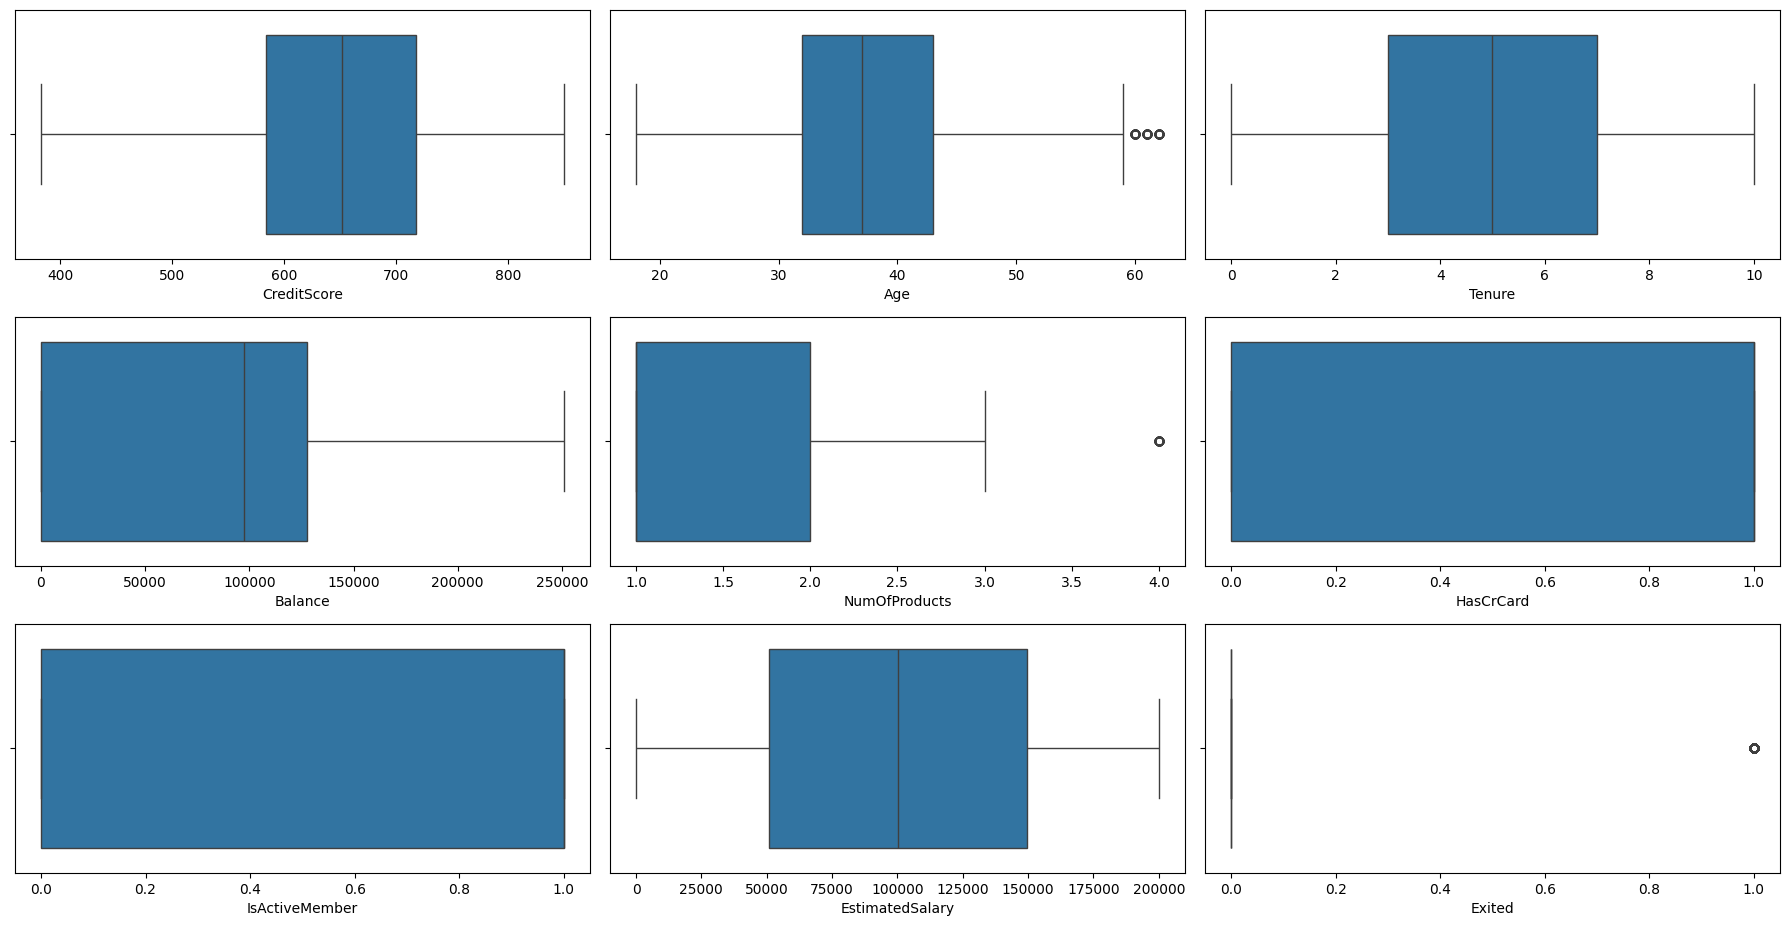

In [14]:
plt.figure(figsize=(18,12))
c=1
for i in df.describe().columns:
    plt.subplot(4,3,c)
    sns.boxplot(x=df[i])
    plt.tight_layout()
    c+=1

In [15]:
x=df.drop('Exited',axis=1)
y=df['Exited']

In [16]:
x=pd.get_dummies(x,drop_first=True,dtype=int)

In [17]:
from sklearn.model_selection import train_test_split as tts
x_train,x_test,y_train,y_test=tts(x,y,test_size=0.2,random_state=42)

In [18]:
from sklearn.preprocessing import RobustScaler
scaler=RobustScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)

In [19]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score,confusion_matrix

# Post Purning & pre purning

In [20]:
#vmax_depth
model4=DecisionTreeClassifier(criterion='log_loss',max_depth=7)
model4.fit(x_train,y_train)
y_pred5=model4.predict(x_test)
print(accuracy_score(y_test,y_pred5))
print(confusion_matrix(y_test,y_pred5))

0.861
[[1554   53]
 [ 225  168]]


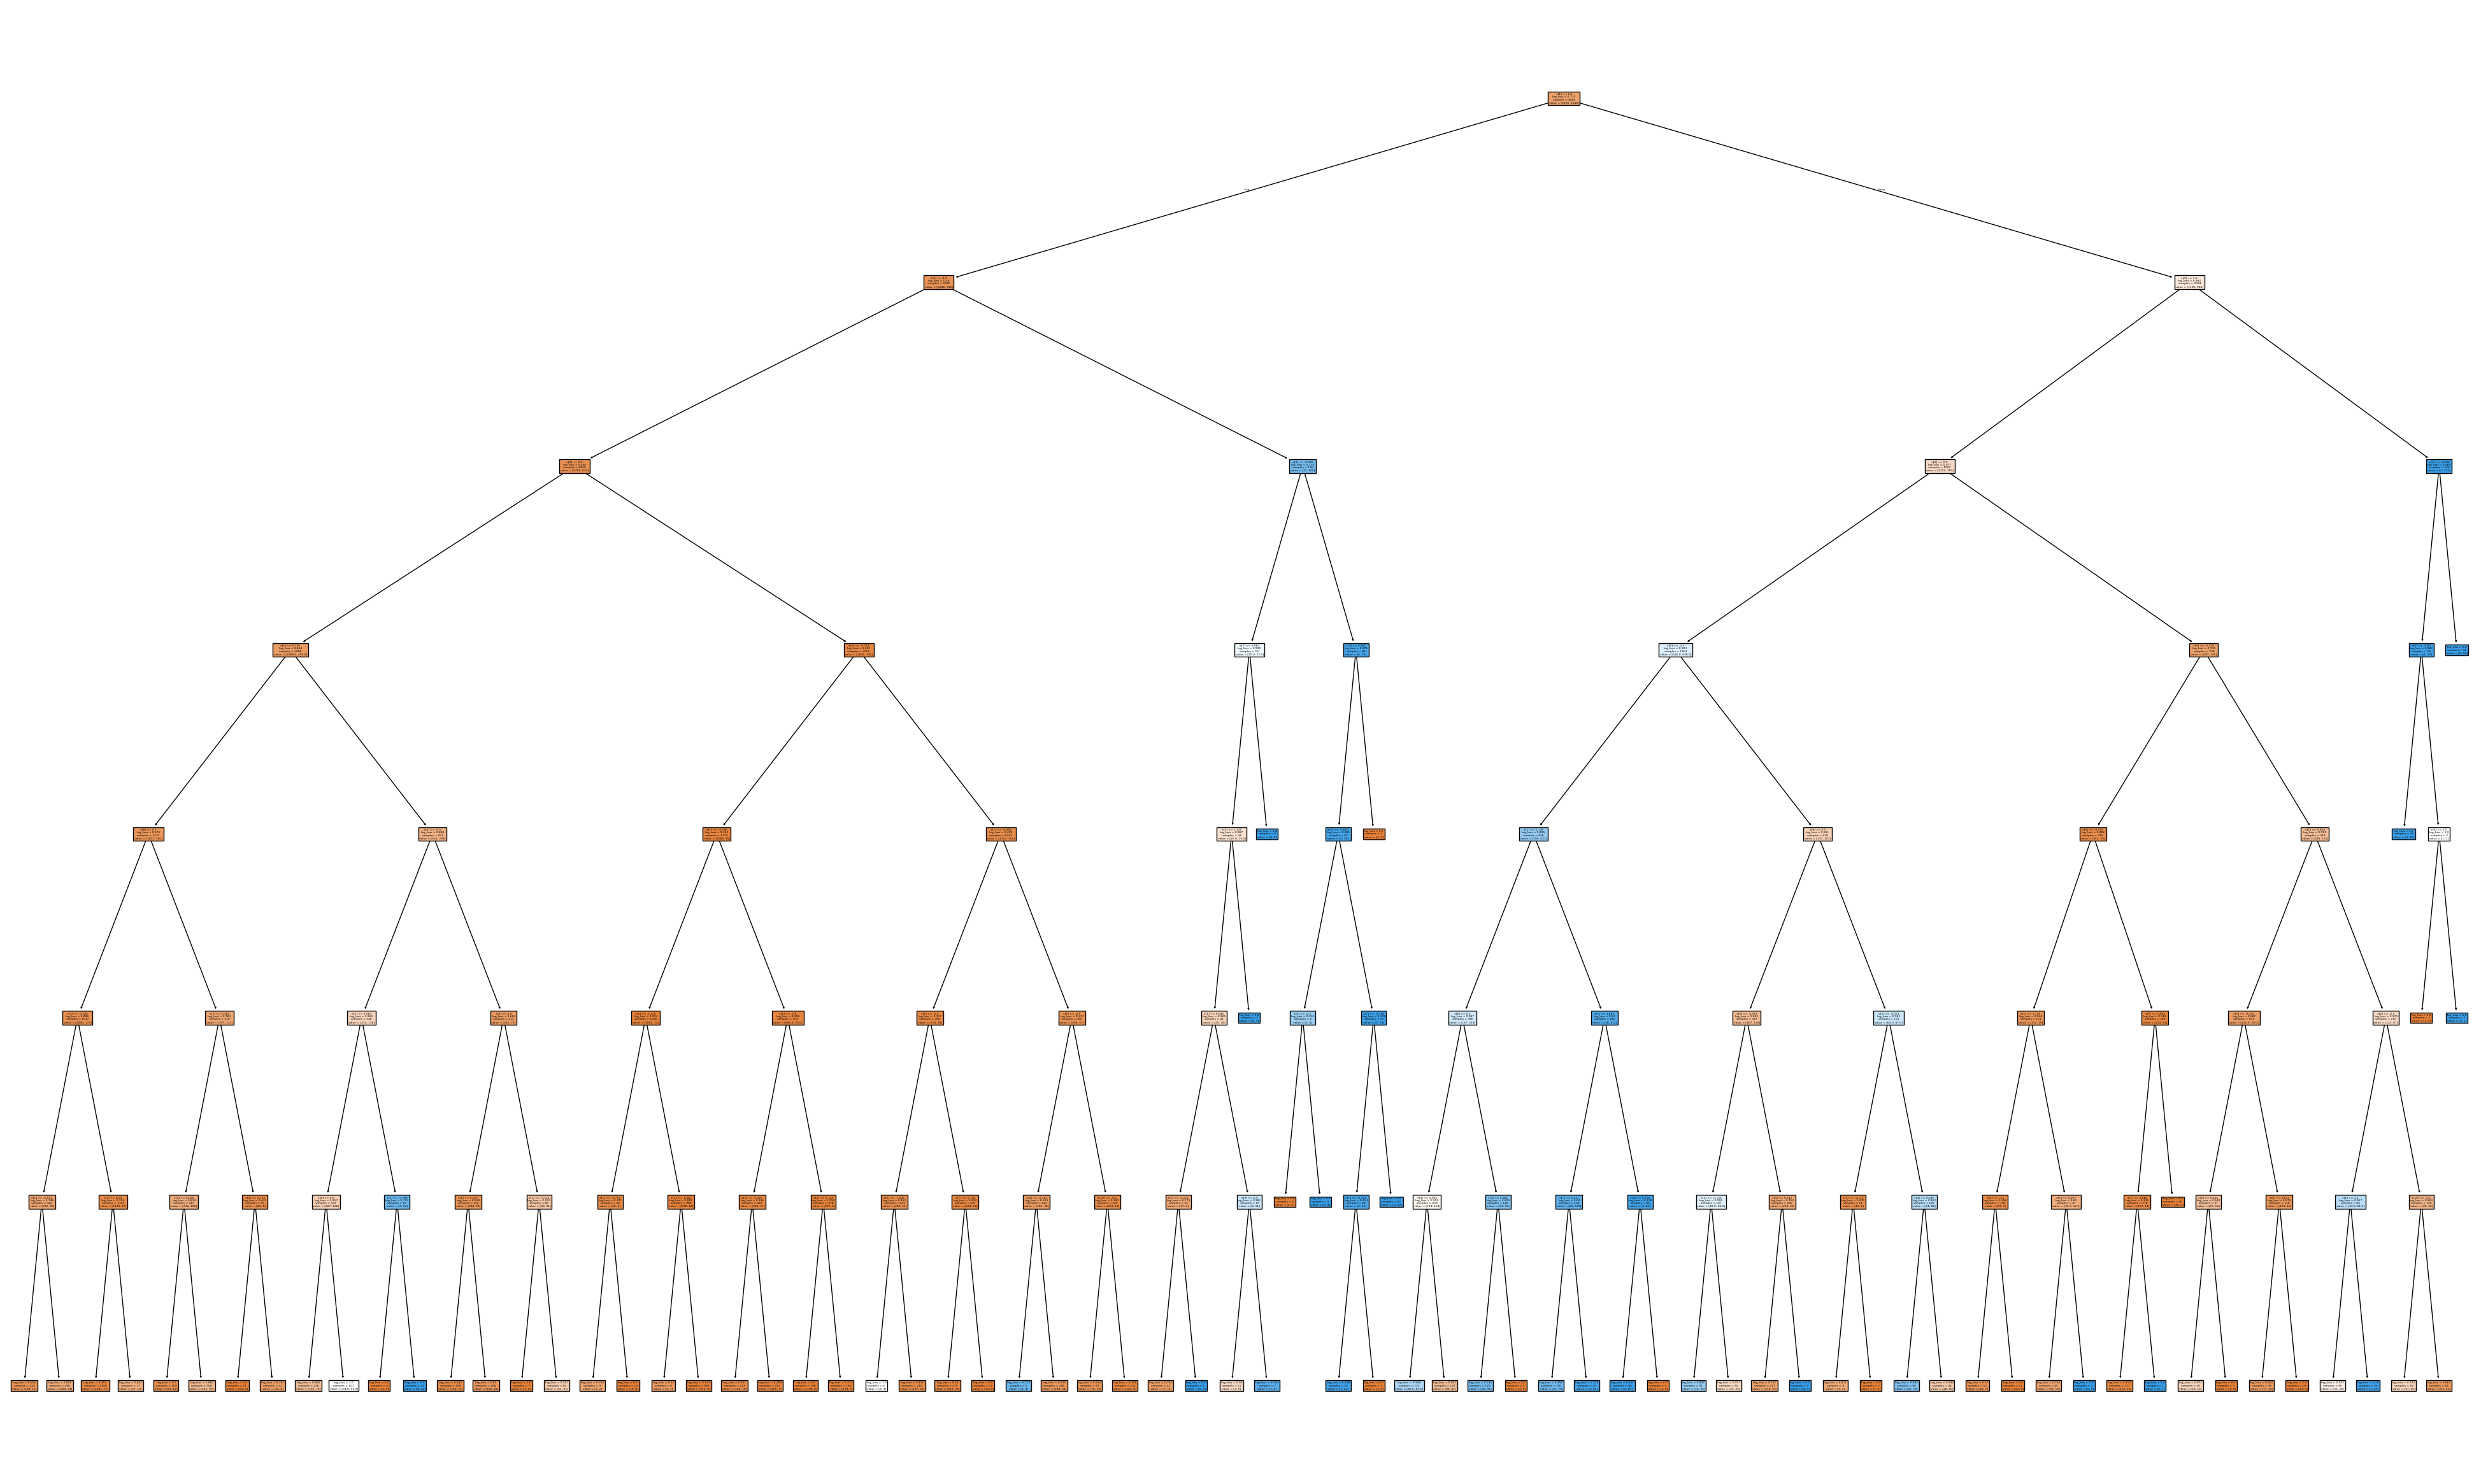

In [21]:
from sklearn.tree import plot_tree
plt.figure(figsize=(50,30))
plot_tree(model4,filled=True)
plt.show()

- hyper parameter tuning (or optimization)
- cross validation
- post pruning
- pre pruning